##### <h1 style="text-align:center"> Drexel University </h1>
<h2 style = "text-align:center"> College of Computing and Informatics</h2>
<h2 style = "text-align:center">DSCI 631: Applied Machine Learning for Data Science</h2>
<h3 style = "text-align:center">Assignment 1</h3>
<h4> </h4>
<div style="text-align:center; border-style:solid; padding: 10px">


<h3 style="color:red; font-weight:bold; text-decoration: underline">DON'T FORGET TO PUT YOUR MEMBERS' NAMES BELOW</h3>
### TEAM MEMBERS: Manyu Ghildiyal

### A. Assignment Overview
This assignment provides the opportunity for you to practice with various skills in data pre-processing, feature analyses, making machine learning precessing pipeline. 

### B. What to Hand In
	
Sumbit a completed this Jupyter notebook. 

### C. How to Hand In

Submit your Jupyter notebook file through the course website in the Blackboard Learn system.

### D. When to Hand In

1. Submit your assignment no later than 11:59 pm in the due date.
2. There will be a 10% (absolute value) deduction for each day of lateness, to a maximum of 3 days; assignments will not be accepted beyond that point. Missing work will earn a zero grade.

### E. Written Presentation Requirements (if applicable)
Images must be clear and legible. Assignments will be judged on the basis of visual appearance, grammatical correctness, and quality of writing, as well as their contents. Please make sure that the text of your assignments is well-structured, using paragraphs, full sentences, and other features of well-written presentation.

### F. Academic Honesty

Each student is required to submit the Academic Honesty Form at the beginning of the term to cover all the deliverables (for example: assignments, projects, quizzes). Each piece of work must be original. That means, individual quizzes must be done individually without discussing and collaborating with anybody else. Team assignments must be written and programmed by your own team members. No team should copy any piece of work from other teams. The Drexel University Academic Honesty Rules and Procedures (as stated in the student handbook) will be adhered to strictly.  

### G. Marking Schemes:

Marking assignments will be based on several aspects: presentation, correctness and coding styles. 

For programming questions, 10% of the mark will be judged on the coding style. 

The following is a set of guidelines for the coding style in this course:
1. Write a good comment.
2. Use appropriate indentations to indicate control flows and blocks of code. 
3. When breaking up a long line, break it before an operator, not after. 

### H. Answer the following questions: 
**Your answer should be combined with code and brief text answer.** Please ensure that your Jupyter notebook does not have too much spurious output. If you like, you can share your notebook in progress with me on Kaggle: leiwangv (lw474@drexel.edu)

### Data for this assignment:
* URL: https://www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset
* On Kaggel Notebook, you can add the data set by searching the above URL
* Column “price” is the target variable to predict.


In [1]:
#All import statements are here for ease of access
#Common Imports
import pandas as pd

#For graph plotting
import matplotlib.pyplot as plt
import seaborn as sns


#For Train/Test Split
from sklearn.model_selection import train_test_split

#Import numpy for loglp
import numpy as np

#Import for Imputing
from sklearn.impute import SimpleImputer

#Import statement for Pipeline & Pre-processing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor

#Import statement for Scalers
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

In [2]:
#Load The Data
kaggleDataset = pd.read_csv('realtor-data.zip.csv')
kaggleDataset.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


#### Question 1:
Examine the features of the data. Identify which feature is continuous and which feature is categorical. Make some analyses and use your analyses to discuss whether each feature could be useful for predicting the "price."

In [3]:
#Used .info() to see the types and all column names
print('1a - Categorical Vs Continuous Features')
kaggleDataset.info()

1a - Categorical Vs Continuous Features
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB


In [4]:
print('1b - Categorical Vs Continuous Features')
kaggleDataset.describe()

1b - Categorical Vs Continuous Features


,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,2.221849e+06,2.224841e+06,1.745065e+06,1.714611e+06,1.900793e+06,2.215516e+06,2.226083e+06,1.657898e+06
mean,5.293989e+04,5.241955e+05,3.275841e+00,2.496440e+00,1.522303e+01,1.012325e+06,5.218668e+04,2.714471e+03
std,3.064275e+04,2.138893e+06,1.567274e+00,1.652573e+00,7.628238e+02,5.837635e+05,2.895408e+04,8.081635e+05
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
25%,2.386100e+04,1.650000e+05,3.000000e+00,2.000000e+00,1.500000e-01,5.063128e+05,2.961700e+04,1.300000e+03
50%,5.288400e+04,3.250000e+05,3.000000e+00,2.000000e+00,2.600000e-01,1.012766e+06,4.838200e+04,1.760000e+03
75%,7.918300e+04,5.500000e+05,4.000000e+00,3.000000e+00,9.800000e-01,1.521173e+06,7.807000e+04,2.413000e+03
max,1.101420e+05,2.147484e+09,4.730000e+02,8.300000e+02,1.000000e+05,2.001357e+06,9.999900e+04,1.040400e+09


In [5]:
#2 - Initial Predictions
print('2a - Initial Predictions Maximum')
sortedKaggleMax = kaggleDataset.sort_values(by='price', ascending=True)
sortedKaggleMax.head()

2a - Initial Predictions Maximum


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
1176582,46047.0,ready_to_build,0.0,3.0,NaN,NaN,1135405.0,Nampa,Idaho,83686.0,2065.0,NaN
1176579,46047.0,ready_to_build,0.0,4.0,NaN,NaN,1135405.0,Nampa,Idaho,83686.0,3259.0,NaN
1176593,46047.0,ready_to_build,0.0,3.0,NaN,NaN,1135405.0,Nampa,Idaho,83686.0,2636.0,NaN
1176592,46047.0,ready_to_build,0.0,3.0,NaN,NaN,1135405.0,Nampa,Idaho,83686.0,2483.0,NaN
1176591,46047.0,ready_to_build,0.0,3.0,NaN,NaN,1135405.0,Nampa,Idaho,83686.0,2007.0,NaN


In [6]:
print('2b - Initial Predictions Minimum')
sortedKaggleMin = kaggleDataset.sort_values(by='price', ascending = False)
sortedKaggleMin.head()

2b - Initial Predictions Minimum


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
221994,23826.0,for_sale,2.147484e+09,2.0,2.0,0.12,11355.0,International,California,NaN,885.0,NaN
941987,104341.0,for_sale,1.000000e+09,NaN,NaN,101.00,129645.0,Eureka,Kansas,67045.0,NaN,NaN
72903,100472.0,for_sale,8.750000e+08,9.0,2.0,NaN,1811391.0,Bronx,New York,10458.0,2440.0,2002-12-30
1288464,13872.0,for_sale,5.150000e+08,2.0,2.0,2.59,1658312.0,San Diego,California,92119.0,1048.0,2018-04-17
2054444,16829.0,sold,2.950000e+08,21.0,49.0,3.83,1805321.0,Los Angeles,California,90077.0,NaN,2022-03-30


In [7]:
print('2c - Correlative Matrix')
cont_corr_matrix = kaggleDataset.select_dtypes(include=['number']).corr()
cont_corr_matrix["price"].sort_values(ascending=False)

2c - Correlative Matrix


price          1.000000
bath           0.178391
bed            0.114761
zip_code       0.038672
acre_lot       0.016166
house_size     0.000254
brokered_by   -0.006318
street        -0.017832
Name: price, dtype: float64

##### 1 - Categorical vs Continuous Features + Initial Analysis

Before beginning the analysis, it is important to define key terms. A continuous feature is a numerical variable that can take on a wide range of values. For example, the number of miles a person walks per day is a continuous feature. In contrast, a categorical feature divides data into distinct groups or categories. For instance, gender is a categorical feature because it classifies individuals into specific groups. With that in mind, we examine the dataset.

There are tweleve features in the dataset: **brokered_by, status, price, bed, bath, acre_lot, street, city, state, zip_code, house_size, prev_sold_date**.

The features which I consider "Categorical" are status (Housing status - a. ready for sale or b. ready to build), city (city name), state (state name), zip_code (postal code of the area), brokered_by (categorically encoded agency/broker), and street (categorically encoded street address). The prev_sold_date feature is also categorical in nature but represents temporal information. The features which I consider "Continuous" are price (Housing price, it is either the current listing price or recently sold price if the house is sold recently), bed (# of beds), bath (# of bathrooms), acre_lot (Property / Land size in acres), and house_size (house area/size/living space in square feet)

Some features require special consideration. The brokered_by and street features behave more like identifiers (features whose primary purpose is to uniquely label each observation in the dataset rather than provide meaningful predictive information), and they also have high cardinality, meaning they contain a very large number of unique values relative to the dataset size. As a result, they are less likely to generalize well and may lead the model to learn patterns that do not apply to new data, making them less useful for prediction.

The zip_code feature is a categorical variable with high cardinality. Unlike identifiers, it represents meaningful geographic regions and may capture important location-based patterns in housing prices. However, its large number of unique values requires careful encoding to avoid excessive dimensionality.

The prev_sold_date feature is a temporal variable in date format. It cannot be directly used in most machine learning models and therefore requires transformation into numerical features, such as extracting the year of last sale or calculating the time elapsed since the previous sale, both of which may help capture market trends and property appreciation effects.

##### 2 - Initial Predictions
Before we go any further, it is important to note that this is a preliminary analysis based on a quick examination of the data. The observations here are intended to guide later modeling and may not fully capture all patterns in the dataset. These observations are also based on extreme values and may not represent overall trends.

To identify features that may influence price, the dataset was sorted by both the highest and lowest values of the target variable, and a correlation matrix was established for numeric values. A few patterns emerged:

* State: Several of the highest-priced houses are located in California, while the lowest-priced houses are located in Idaho. This suggests that location at the state level may significantly influence price.
* Status: The lowest-priced houses are labeled as ready_to_build, whereas the highest-priced houses are primarily for_sale. This indicates that housing status may be an important predictor of price
* Bath: Based on the correlation matrix, the number of bathrooms shows the strongest positive correlation with price among the numerical features, suggesting that larger homes tend to have higher value.
    * However, it is important to note that all correlations are relatively weak (close to 0), indicating that no single numerical feature has a strong linear relationship with price.

Based on this initial analysis, features such as state and status appear to be strong candidates for predicting price, along with numerical features such as bath and bed. Other features appear to have weaker relationships with price at this stage, but they will still be evaluated further through modeling and preprocessing steps.

#### Question 2:
Create plots to visualize the distribution of the target "price" vs the distribution of  each predictors. Do you notice anything that might require special treatment? Discuss your findings and suggestions on wrangling the data for the prediction task.

##### Price Graph

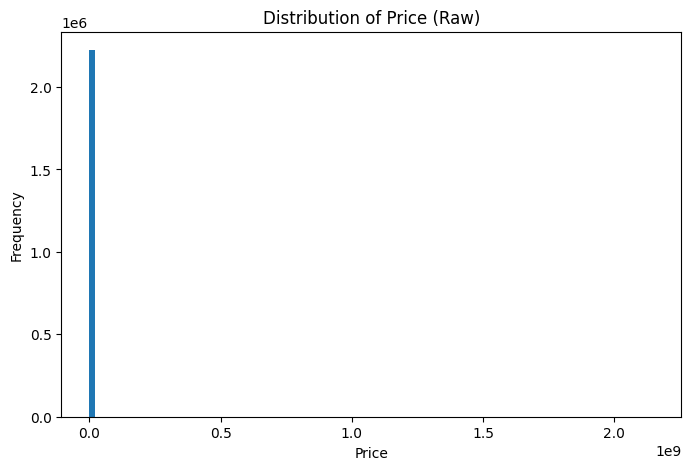

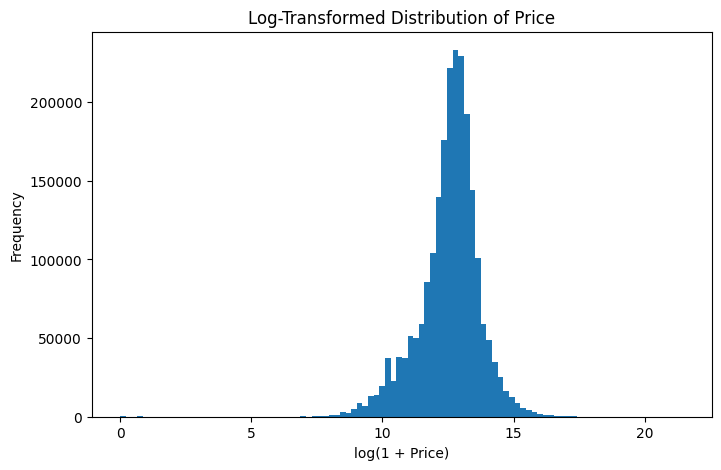

In [8]:
#Raw Price
plt.figure(figsize=(8,5))
plt.hist(kaggleDataset['price'], bins=100)
#Titles and Axis
plt.title("Distribution of Price (Raw)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


#Log-Transformed Price - For Insight Only
plt.figure(figsize=(8,5))
#log1p changes 
plt.hist(np.log1p(kaggleDataset['price']), bins=100)
#Titles and Axes
plt.title("Log-Transformed Distribution of Price")
plt.xlabel("log(1 + Price)")
plt.ylabel("Frequency")
plt.show()

##### Categorical Fratures

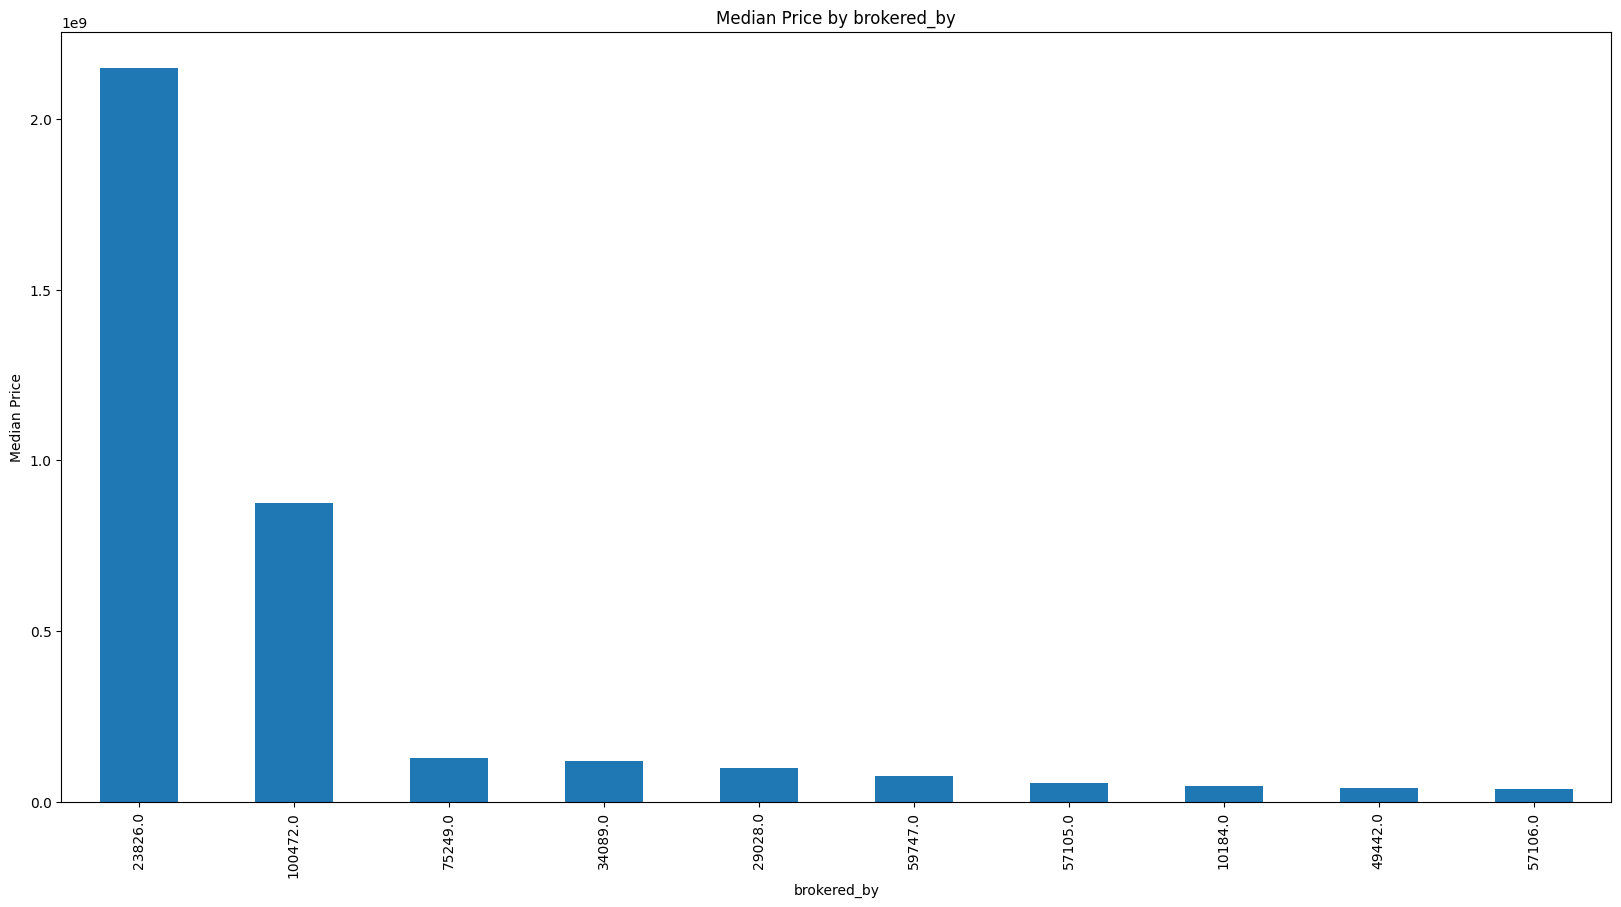

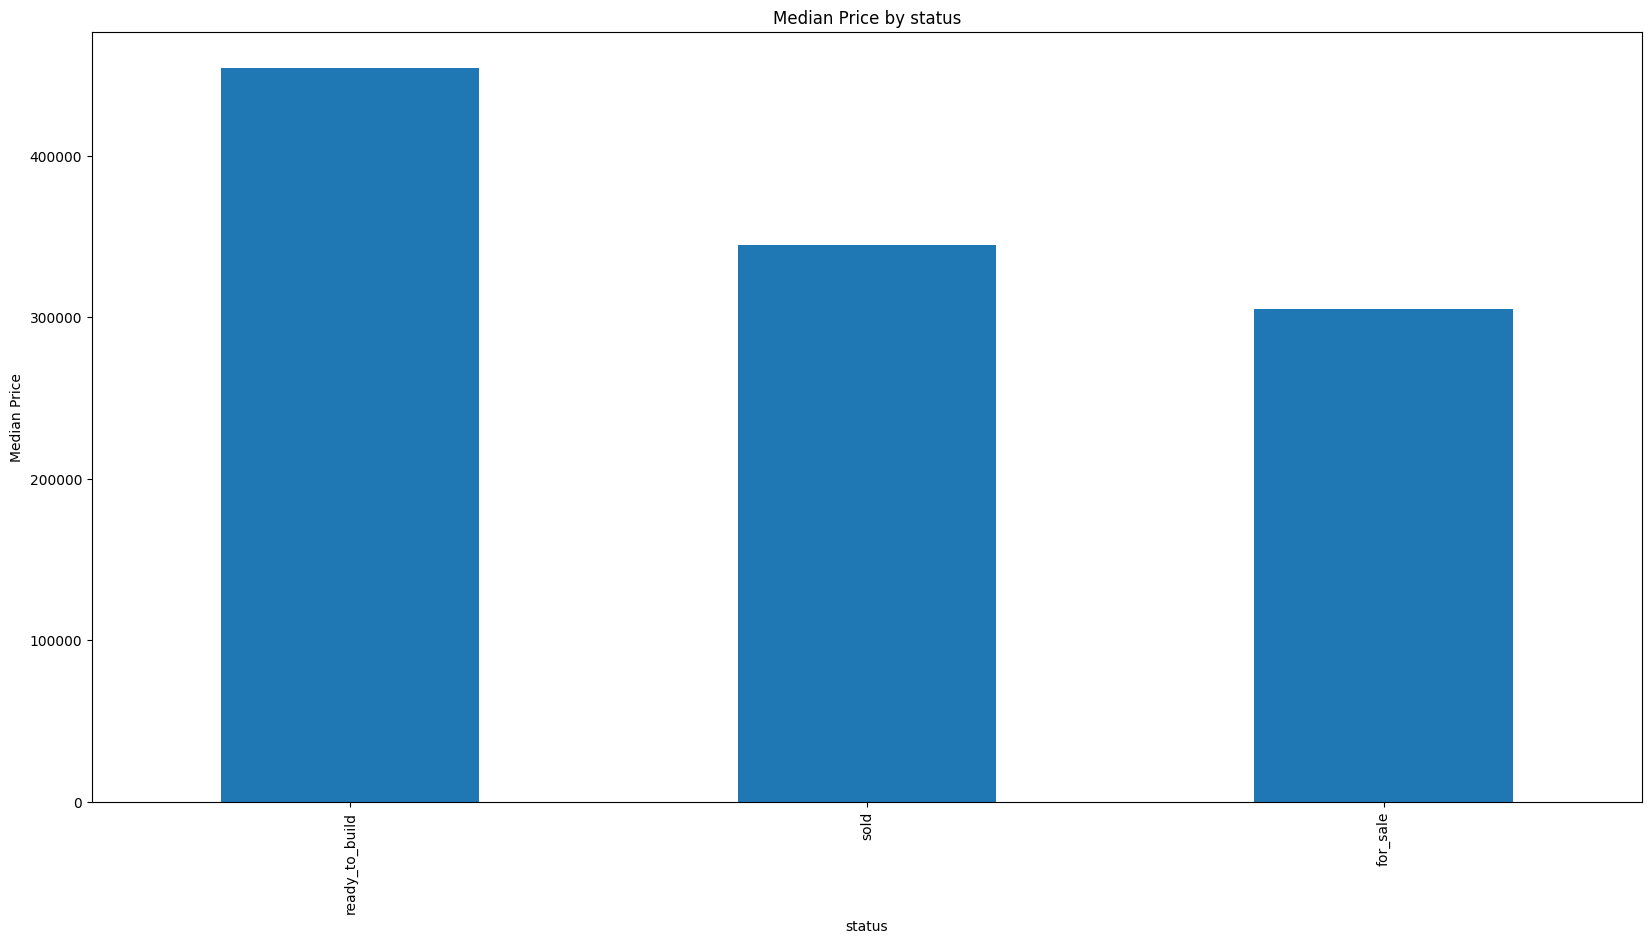

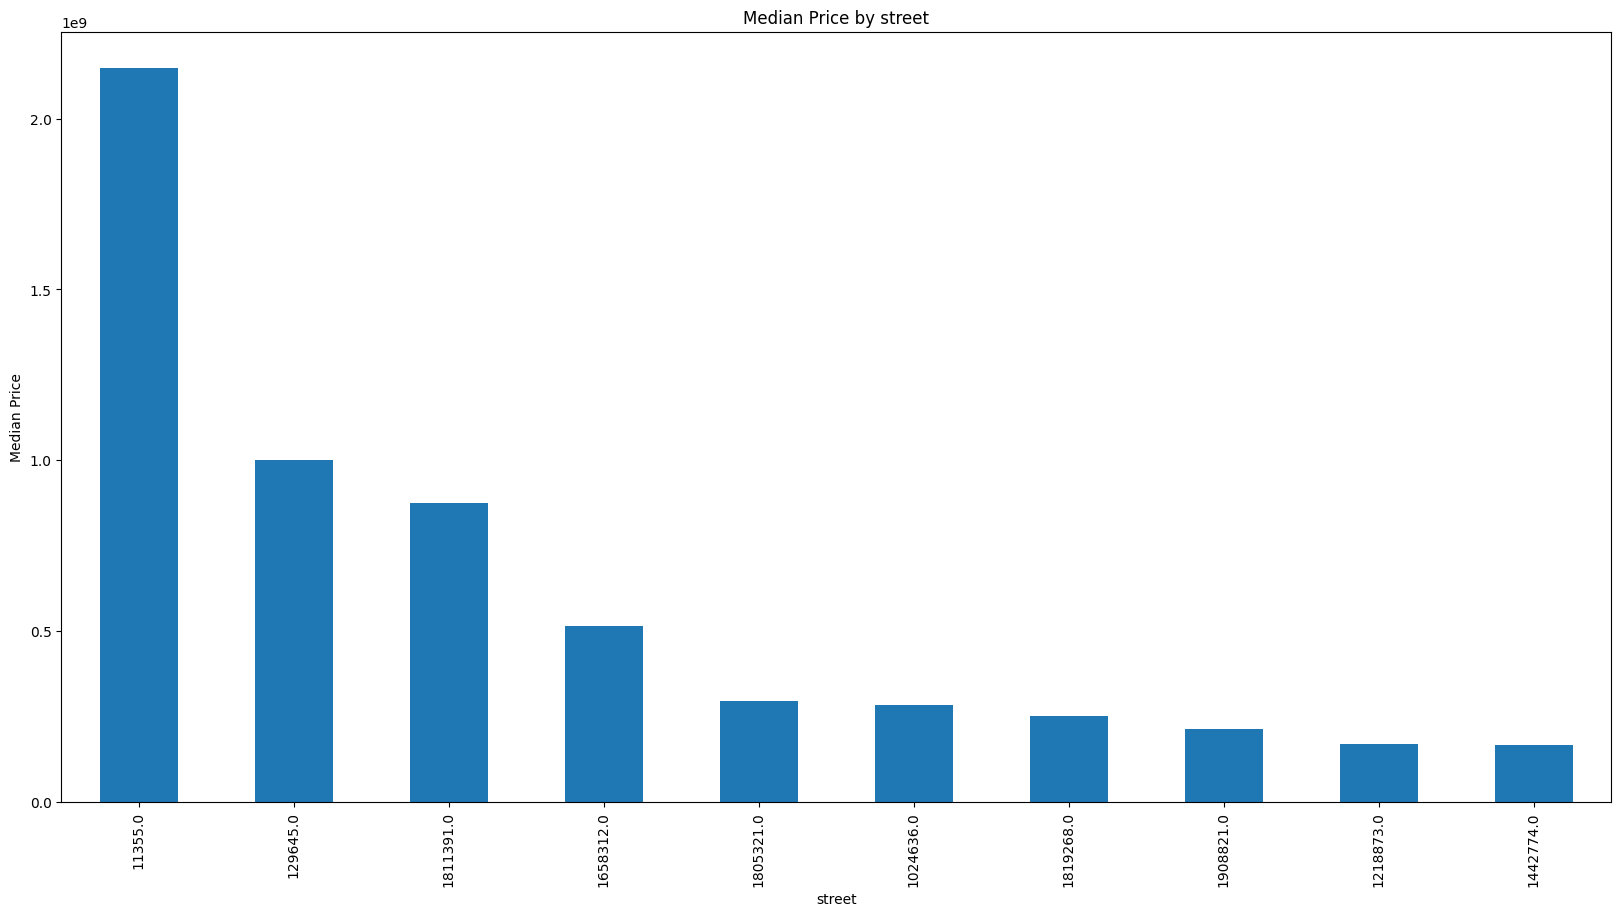

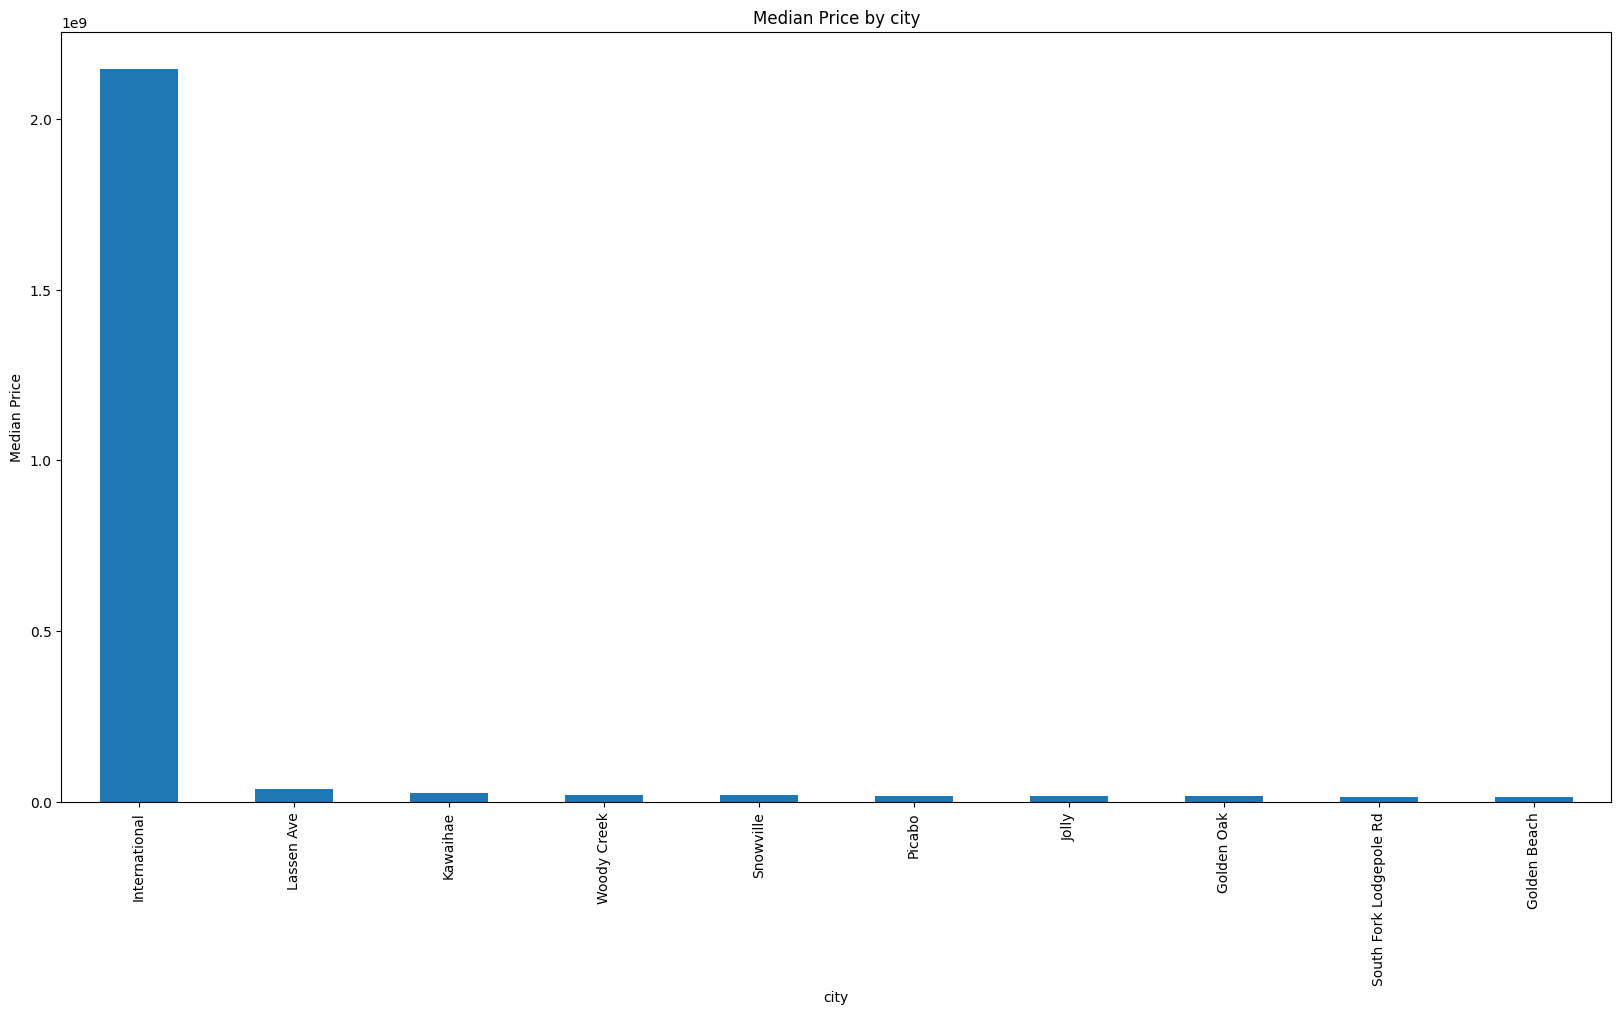

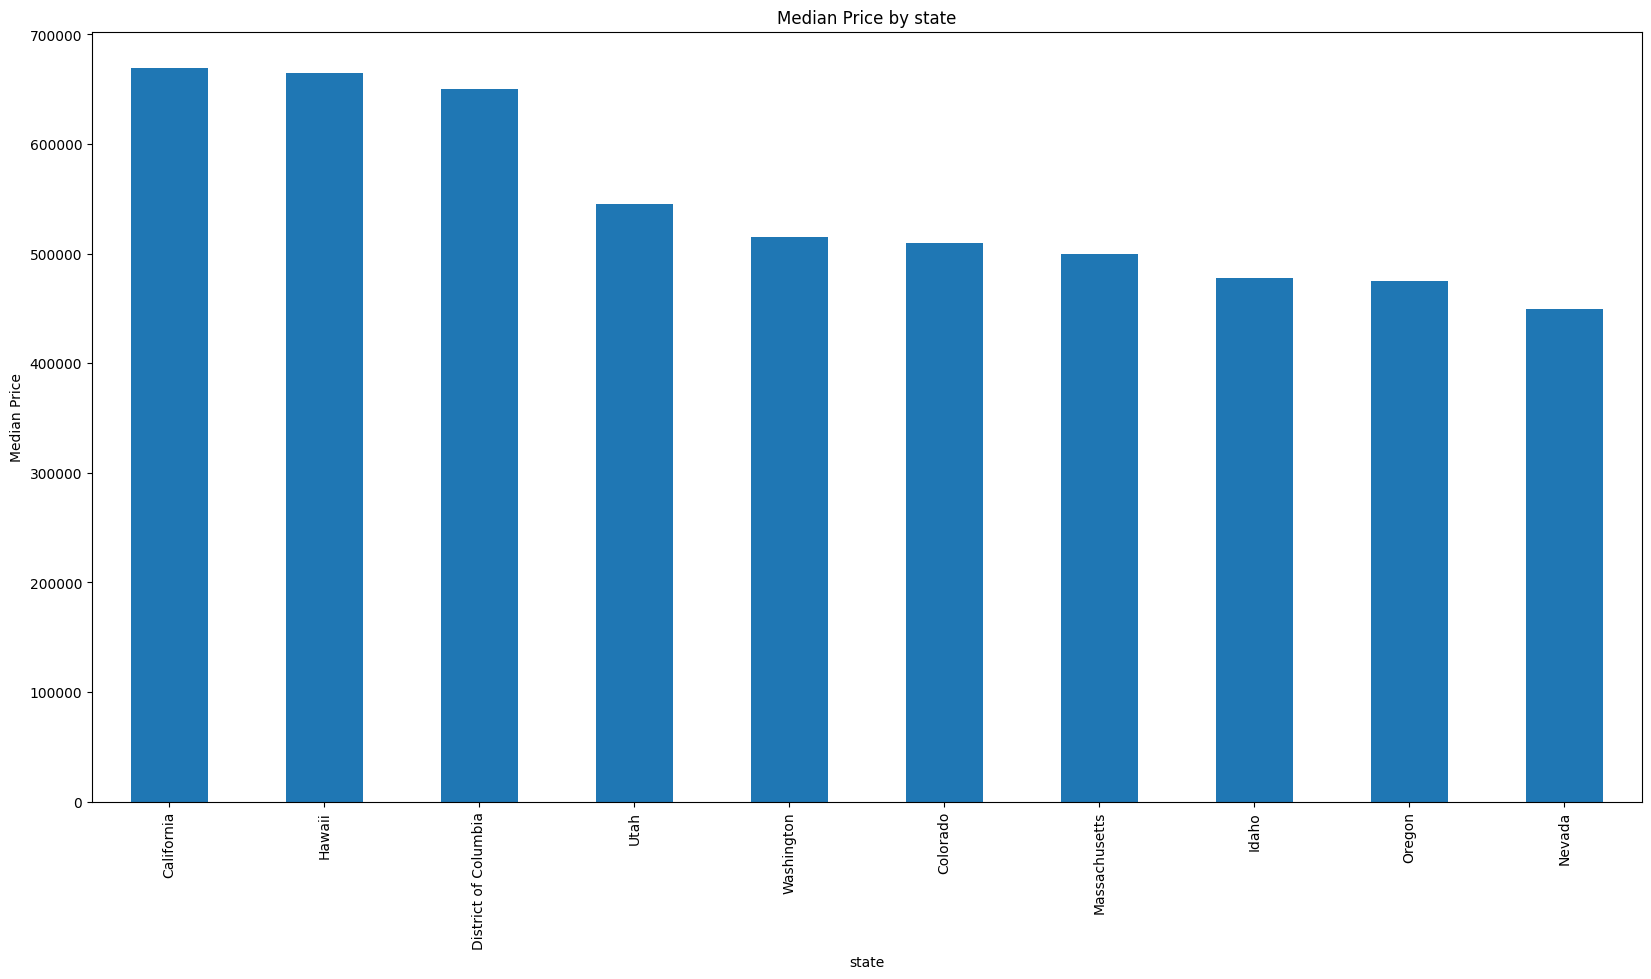

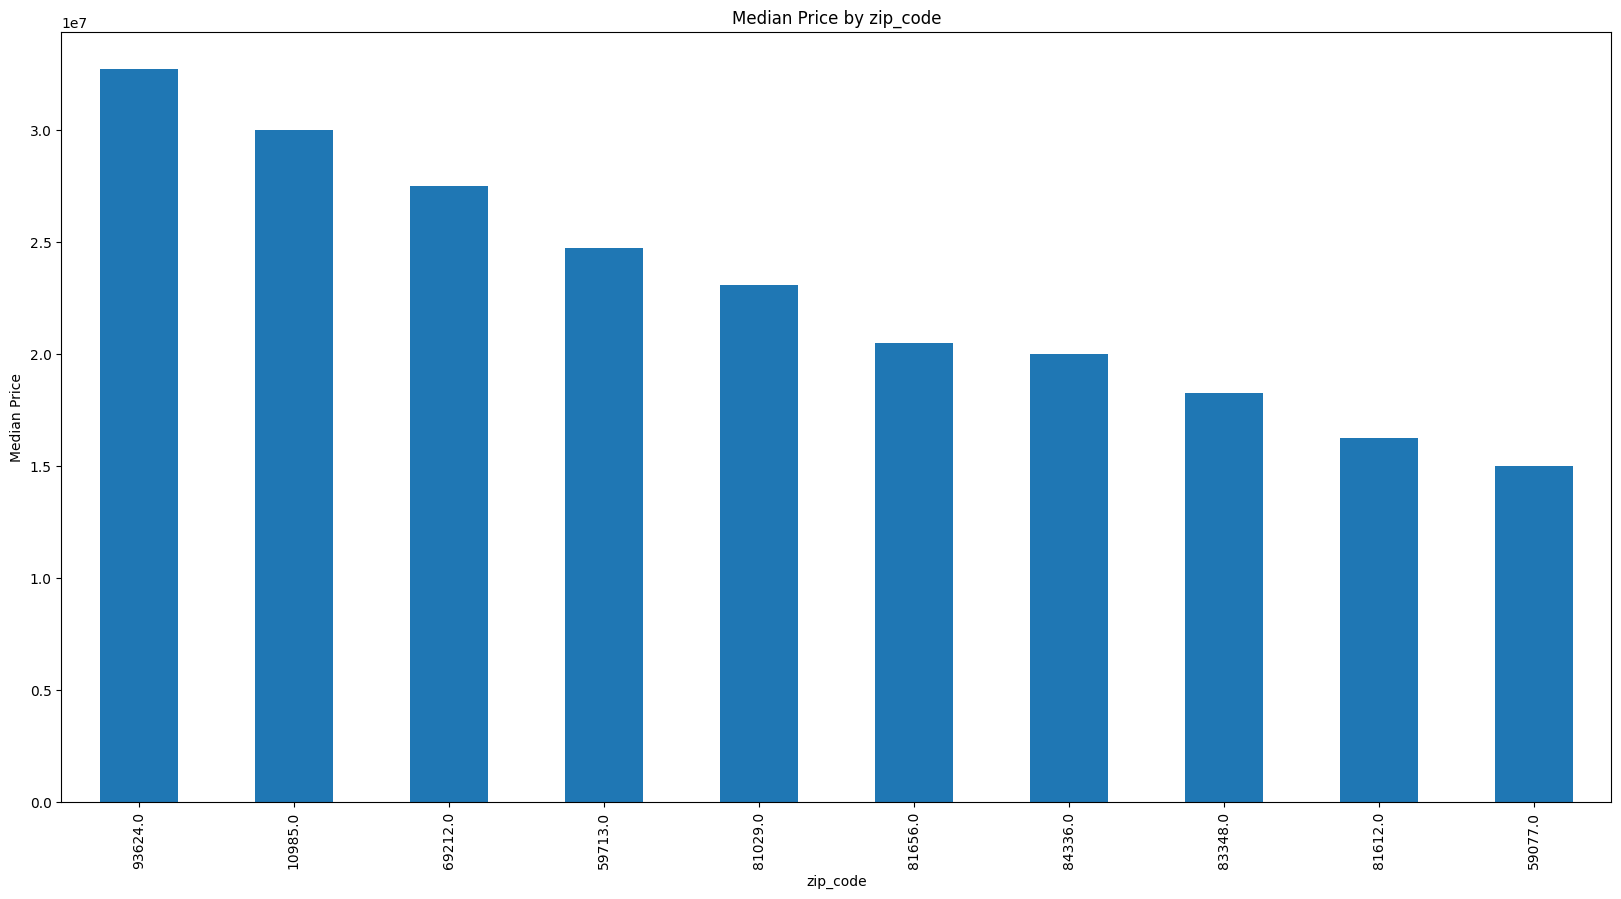

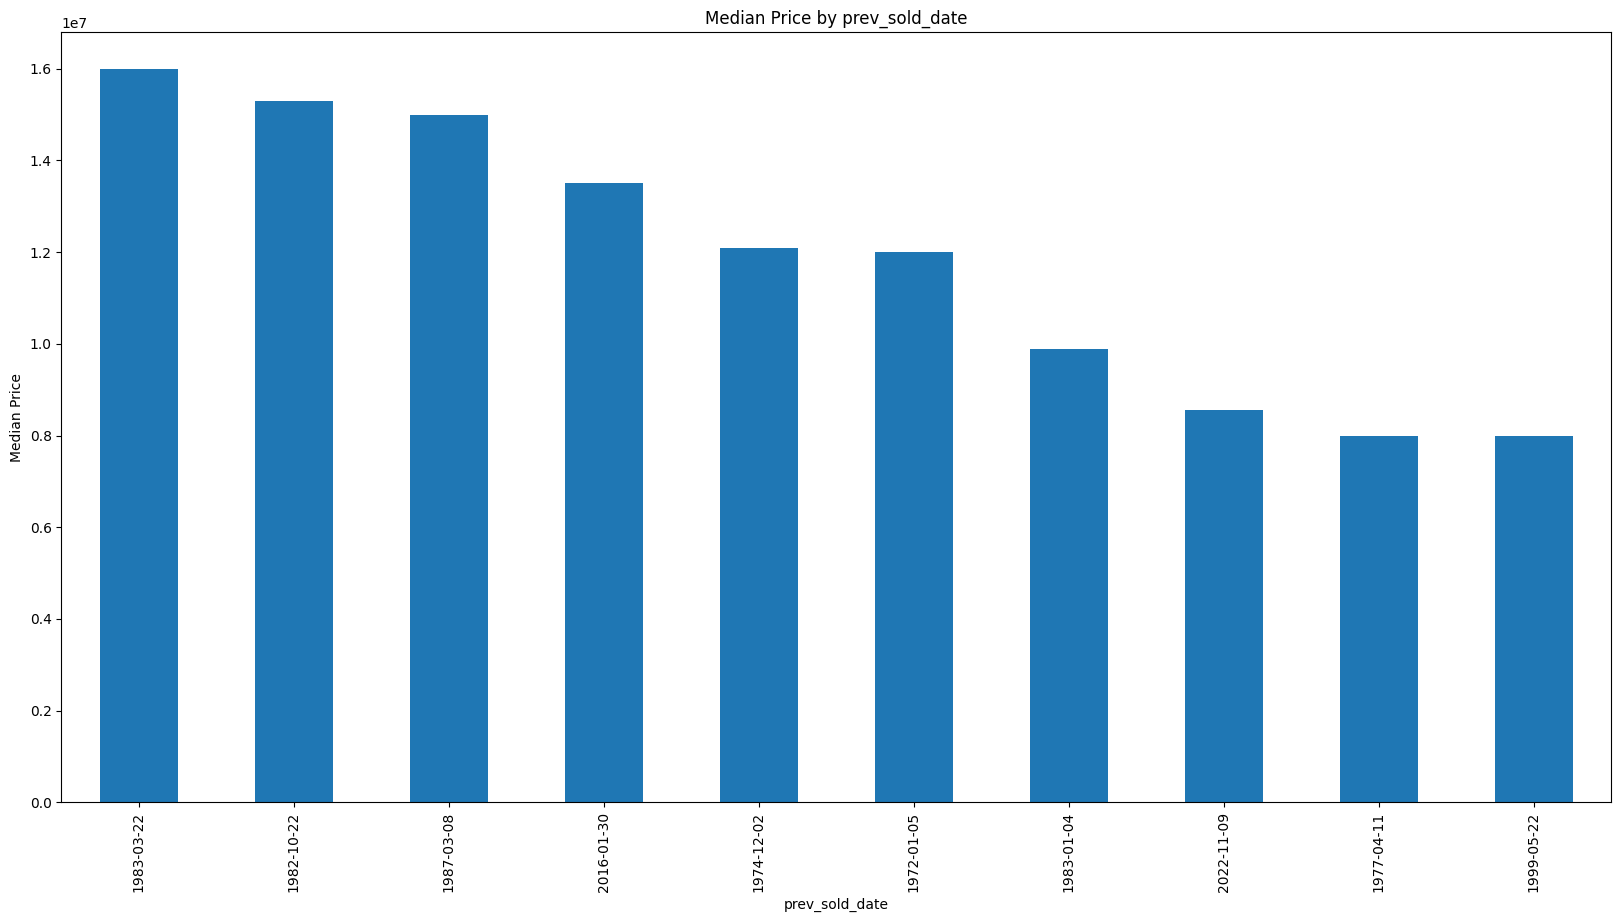

In [9]:
cat_col = ['brokered_by', 'status', 'street', 'city', 'state', 'zip_code', 'prev_sold_date']

for col in cat_col:
    #Group by col and price.
    median_price = (kaggleDataset.groupby(col)['price']
        #Calculates the Median.Median means the middle value in a set of numbers when they are arranged in ascending order 
        .median()
        #It then sort the values by greatest to least
        .sort_values(ascending=False)
        #It then the first 10
        .head(10))
    
    #Plot bar chart
    plt.figure(figsize=(20,10))
    median_price.plot(kind='bar')
    
    #Title and Axis Name
    plt.xlabel(f'{col}')
    plt.ylabel('Median Price')
    plt.title(f'Median Price by {col}')
    plt.show()

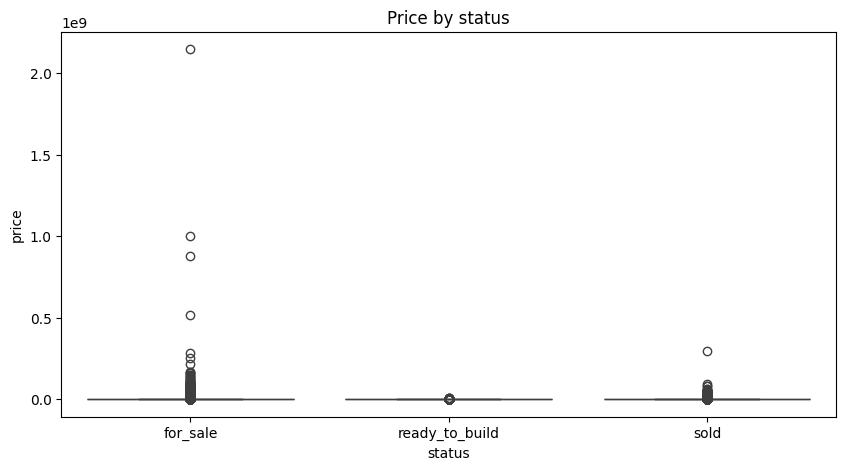

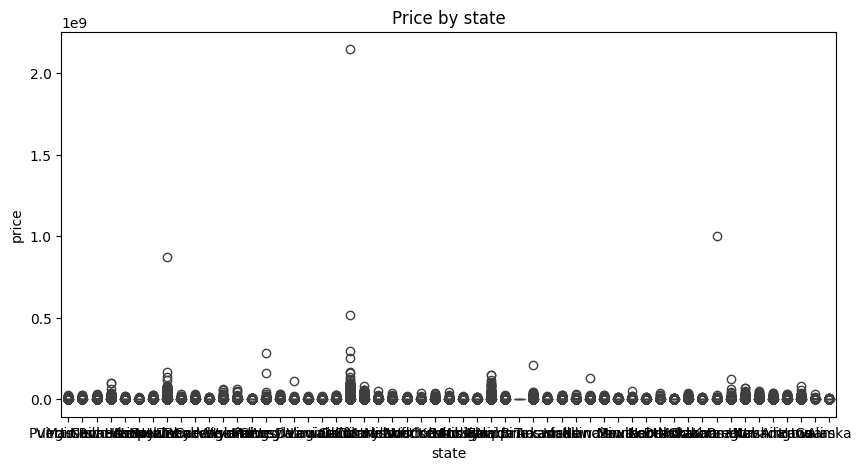

In [ ]:
cat_col = ['status', 'state','city']

for col in cat_col:
    plt.figure(figsize=(10,5))
    #Create a boxplot
    sns.boxplot(x=col, y='price', data=kaggleDataset)
    #Create a Title
    plt.title(f"Price by {col}")
    plt.show()

##### Continuous Features

In [ ]:
#Same as before
cont_col = ['bed', 'bath', 'acre_lot','house_size']

for col in cont_col:
    plt.figure(figsize=(6,4))
    #Create a Scatter Plot
    plt.scatter(kaggleDataset[col], kaggleDataset['price'], alpha=0.3)
    #Titles & Labels
    plt.title(f"{col} vs Price")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.show()

##### Observation:

* The target variable (price) is highly right-skewed, with a small number of extreme high-value outliers dominating the distribution. This indicates that the data is not normally distributed and requires transformation for modeling.
* Applying a log transformation reduces the skewness of the price distribution and produces a more balanced, bell-shaped curve. This suggests that scaling or transformation with similar techniques may improve model performance.
* Some features, particularly state and status, show clear and meaningful differences in price distribution. Certain states (e.g. California) tend to have significantly higher median prices, indicating that location is a strong predictor of housing value.
* Numerical features such as bed, bath, acre_lot, and house_size show weak relationships with price. These relationships are not strictly linear and are affected by noise and outliers.
* Features such as city, brokered_by, and street are highly right-skewed due to high cardinality, meaning they contain a very large number of unique values. If used as predictors, they would require careful transformation or encoding to be usable in a machine learning model.
* The dataset contains variables with highly varying value ranges.
* Nearly all features contain missing values, which will need to be addressed during the preprocessing stage. However, this is left for later analysis and modeling steps

Overall, the analysis shows that location-based features such as state and status have the strongest observable relationship with price, while numerical features exhibit weaker and less consistent patterns. Several variables also show issues such as skewness and high cardinality. However, these issues do not necessarily imply that the features are uninformative, as appropriate preprocessing and transformation may reveal additional predictive value.

The insights from this exploratory analysis will inform feature selection and preprocessing strategies in Question 4, where decisions regarding feature retention, transformation, and missing value handling will be made.

#### Question 3: 
Split the data into train and test data, What parameters do you use for splitting the data? Why? Do you apply stratified sampling? Why or Why not?

In [ ]:
#Dropna Values
kaggleDataset = kaggleDataset.dropna(subset=['price'])

#Stratifying Sampling 
kaggleDataset['price_bin'] = pd.qcut(kaggleDataset['price'],q=5,labels=[1,2,3,4,5])

# Simple Train-Test split using kaggleDataset
train_set, test_set = train_test_split(kaggleDataset, test_size=0.2, random_state=42,stratify=kaggleDataset['price_bin'] )

#Remove Helper Column
train_set = train_set.drop("price_bin", axis=1)
test_set = test_set.drop("price_bin", axis=1)

In [ ]:
#Test Debug
print("Test Head")
test_set.head()

In [ ]:
#Train Debug
print("Train Head")
train_set.head()

##### Analysis: 
Before splitting the dataset, rows with missing values in the target variable (price) were removed so it would not cause errors during model training.

I performed a standard train-test split where the dataset was divided into two subsets: a training set and a test set. I used an 80/20 split, which is a commonly used ratio. I also set a fixed random state so the split is reproducible, meaning I get the same split every time I run the code.

To improve the quality of the split, I used stratified sampling. Stratified sampling is a method where the data is split in a way that keeps the same overall distribution of a chosen variable in both the training and test sets. Since this is a regression problem and house prices are continuous, I first grouped the prices into 5 categories using quantile-based binning. This turns the continuous price values into ranges like low, medium, and high. I then used these groups for stratification when splitting the data. This helps make sure both the training and test sets have a similar mix of cheap and expensive houses.

The main reason for doing this is to avoid sampling bias. Without stratification, it’s possible that one split ends up with mostly cheap houses or mostly expensive ones, which would give a misleading idea of how well the model actually performs. For example, International, California has a lot of high-priced homes, those would mostly fall into the highest quantile (Bin 5), while cheaper homes from other areas would fall into the lower bins. By using stratified sampling, I made sure both datasets reflect the same overall distribution, which makes the evaluation more fair and reliable.

#### Question 4:
For the features you have identified that could be useful for predicting the "price", which ones have missing values? Should we drop the instances with missing values or should we impute? If choose to impute, what strategies would you choose and why? apply your strategy

##### Analysis - Choosing the Features:

Before addressing missing values, it is important to first define the feature set used for modeling. In this model, I have reduced the feature set by removing high-cardinality and weakly informative variables such as city and acre_lot. These features either introduced noise or showed weak correlation with the target variable during exploratory analysis.

The final selection focuses on core structural and location-based features that demonstrate stronger and more consistent relationships with price, improving model simplicity and generalization.

This feature set is:
* state
* status
* bed
* bath
* house_size

In [ ]:
#List of chosen features
col_list = ['state','status','bed','bath','house_size']
print("Missing values per selected feature:\n")
for col in col_list:
    print(f'Train Set - {col}:')
    print(train_set[col].isna().sum())
    print(f'Test Set - {col}:')
    print(test_set[col].isna().sum())
    print('\n')

##### Analysis - Dealing With Empty Cells:
When addressing missing values, different imputation strategies were applied based on the type of feature. For categorical features such as state, the most frequent value (mode) was used to fill missing entries. This approach preserves the most common category and maintains the distribution of the data.

For numerical features (bed, bath, and house_size), median imputation was used. The median was chosen because it is robust to outliers and skewed distributions, which are present in the dataset. This ensures that extreme values do not disproportionately influence the imputed results.

This combined approach allows for appropriate handling of both categorical and numerical data while ensuring that the dataset contains no missing values prior to model training.

In [ ]:
# Feature groups
cat_features = ['state']
num_features = ['bed', 'bath', 'house_size']

#Categorical Features
cat_imputer = SimpleImputer(strategy='most_frequent')
train_set[cat_features] = cat_imputer.fit_transform(train_set[cat_features])
test_set[cat_features] = cat_imputer.transform(test_set[cat_features])

#Continuous Features
num_imputer = SimpleImputer(strategy='median')
train_set[num_features] = num_imputer.fit_transform(train_set[num_features])
test_set[num_features] = num_imputer.transform(test_set[num_features])

#Debug To Make Sure there are no empties in features
print('Train Set:')
print(train_set[cat_features + num_features].isna().sum())
print('Test Set:')
print(test_set[cat_features + num_features].isna().sum())

#### Question 5: 
Build Pipeline, apply transformer as needed, train Linear Regression and Decision Tree models with default parameters, make predictions on test set. Discuss your results and findings.


In [ ]:
# Pre-processing setup
cat_features = ['state', 'status']
num_features = ['bed', 'bath', 'house_size']


#Train Test Split
x_train = train_set[cat_features + num_features]
x_test = test_set[cat_features + num_features]
y_train = train_set['price']
y_test = test_set['price']

# Log-transform target - Data is right-skewed
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)


# Creating Pipeline
full_pipeline = ColumnTransformer([
    ("cat", OneHotEncoder(), cat_features),
    ("num", "passthrough", num_features)
])


# Linear Regression model
lin_reg = Pipeline([
    ('preprocessor', full_pipeline),
    ('model', LinearRegression())
])

# Decision Tree model
tree_reg = Pipeline([
    ('preprocessor', full_pipeline),
    ('model', DecisionTreeRegressor(
        random_state=42,
        max_depth=10,
        min_samples_split=10
    ))
])


#Train Models
lin_reg.fit(x_train, y_train_log)
tree_reg.fit(x_train, y_train_log)
lr_preds_log = lin_reg.predict(x_test)
tree_preds_log = tree_reg.predict(x_test)


# Convert back to original price scale
lr_preds = np.expm1(lr_preds_log)
tree_preds = np.expm1(tree_preds_log)


#Results:
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("\nDecision Tree")
print("MAE:", mean_absolute_error(y_test, tree_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, tree_preds)))

#####  Analysis:

The Decision Tree model performed better than Linear Regression in terms of both MAE and RMSE. This suggests that the relationship between housing features and price is not linear, and that nonlinear models are better suited for this dataset. Despite this improvement, both models still produced relatively high error values, indicating that the prediction task is inherently difficult due to the complexity, noise, and variability in housing prices.

One key observation from earlier is that the numerical features (bed, bath, house_size) showed relatively weak linear correlation with price. However, this does not imply that these features are uninformative. Instead, it suggests that their relationship with price is likely nonlinear, which is better captured by tree-based models than linear regression.

Another important limitation is that location-based information plays a major role in determining housing prices, but the dataset only provides geographic features such as state. More granular location signals (such as school distrcit or income level) are not available, while features like city and street are available but were excluded due to very high cardinality and noise.

Additionally, the dataset contains extreme values and a heavily right-skewed price distribution. Although a log transformation can help stabilize variance and reduce skewness, the presence of outliers and large variability across regions still makes accurate prediction challenging.

In terms of improvement, one promising direction would be more advanced feature engineering, particularly more effective encoding of location (for example, target encoding or frequency encoding for high-cardinality variables such as city or zip code). Another improvement would be experimenting with more powerful models such as Random Forests or Gradient Boosting, which are typically better at handling nonlinear relationships and interactions in structured tabular data.


#### Quesetion 6:
Choose two columns of `X_train`, apply differnt feature scaling methods (Sandard scalar, MinMax Scalar, Robust Scalar) introduced in Week 1 Jupyter Notebook on them. Compare the data distribution after scaling with original value using visualization.

##### Creating Models:

In [ ]:
#New Columns of x_train
num_features = ['bed', 'bath']
x_train = train_set[num_features]
x_test = test_set[num_features]
y_train = train_set['price']
y_test = test_set['price']


#StandardScaler Model
std_pipeline = ColumnTransformer([
    ("num", StandardScaler(), num_features)
])

std_model = Pipeline([
    ("preprocessor", std_pipeline),
    ("tree", DecisionTreeRegressor(
        random_state=42,
        max_depth=10,
        min_samples_split=10
    ))
])

std_model.fit(x_train, y_train)
std_preds = std_model.predict(x_test)


#MinMaxScaler Model
mm_pipeline = ColumnTransformer([
    ("num", MinMaxScaler(), num_features)
])

mm_model = Pipeline([
    ("preprocessor", mm_pipeline),
    ("tree", DecisionTreeRegressor(
        random_state=42,
        max_depth=10,
        min_samples_split=10
    ))
])

mm_model.fit(x_train, y_train)
mm_preds = mm_model.predict(x_test)



#RobustScaler Model
rb_pipeline = ColumnTransformer([
    ("num", RobustScaler(), num_features)
])

rb_model = Pipeline([
    ("preprocessor", rb_pipeline),
    ("tree", DecisionTreeRegressor(
        random_state=42,
        max_depth=10,
        min_samples_split=10
    ))
])

rb_model.fit(x_train, y_train)
rb_preds = rb_model.predict(x_test)

#Output Statement - Just to Debug
std_MAE = mean_absolute_error(y_test, std_preds)
std_RMSE = np.sqrt(mean_squared_error(y_test, std_preds))
mm_MAE = mean_absolute_error(y_test, mm_preds)
mm_RMSE = np.sqrt(mean_squared_error(y_test, mm_preds))
rb_MAE = mean_absolute_error(y_test, rb_preds)
rb_RMSE = np.sqrt(mean_squared_error(y_test, rb_preds))

print("StandardScaler")
print("MAE:", std_MAE)
print("RMSE:", std_RMSE)
print("\nMinMaxScaler")
print("MAE:", mm_MAE)
print("RMSE:", mm_RMSE)
print("\nRobustScaler")
print("MAE:", rb_MAE)
print("RMSE:", rb_RMSE)

##### Feature Distribution:

In [ ]:
# =========================================================
#FEATURE DISTRIBUTION COMPARISON
#Shape
#Range
#Spread
# =========================================================

#Create pandas to make it easier to access
x_standard_df = pd.DataFrame(
    std_pipeline.transform(x_train),
    columns=num_features
)

x_mm_df = pd.DataFrame(
    mm_pipeline.transform(x_train),
    columns=num_features
)

x_rb_df = pd.DataFrame(
    rb_pipeline.transform(x_train),
    columns=num_features
)

print("\n===== FEATURE DISTRIBUTION COMPARISON =====\n")


print("ORIGINAL DATA")
orig_bed_shape = x_train['bed'].shape
orig_bed_range = (x_train['bed'].min(), x_train['bed'].max())
orig_bed_std = x_train['bed'].std()
orig_bath_shape = x_train['bath'].shape
orig_bath_range = (x_train['bath'].min(), x_train['bath'].max())
orig_bath_std = x_train['bath'].std()
print("bed")
print("Shape:", orig_bed_shape)
print("Range:", orig_bed_range)
print("Spread (std):", orig_bed_std)
print()
print("bath")
print("Shape:", orig_bath_shape)
print("Range:", orig_bath_range)
print("Spread (std):", orig_bath_std)
print("\n")



print("STANDARD SCALER")
std_bed_shape = x_standard_df['bed'].shape
std_bed_range = (x_standard_df['bed'].min(), x_standard_df['bed'].max())
std_bed_std = x_standard_df['bed'].std()
std_bath_shape = x_standard_df['bath'].shape
std_bath_range = (x_standard_df['bath'].min(), x_standard_df['bath'].max())
std_bath_std = x_standard_df['bath'].std()
print("bed")
print("Shape:", std_bed_shape)
print("Range:", std_bed_range)
print("Spread (std):", std_bed_std)
print()
print("bath")
print("Shape:", std_bath_shape)
print("Range:", std_bath_range)
print("Spread (std):", std_bath_std)
print("\n")



print("MINMAX SCALER")
mm_bed_shape = x_mm_df['bed'].shape
mm_bed_range = (x_mm_df['bed'].min(), x_mm_df['bed'].max())
mm_bed_std = x_mm_df['bed'].std()
mm_bath_shape = x_mm_df['bath'].shape
mm_bath_range = (x_mm_df['bath'].min(), x_mm_df['bath'].max())
mm_bath_std = x_mm_df['bath'].std()
print("bed")
print("Shape:", mm_bed_shape)
print("Range:", mm_bed_range)
print("Spread (std):", mm_bed_std)
print()
print("bath")
print("Shape:", mm_bath_shape)
print("Range:", mm_bath_range)
print("Spread (std):", mm_bath_std)
print("\n")


print("ROBUST SCALER")
rb_bed_shape = x_rb_df['bed'].shape
rb_bed_range = (x_rb_df['bed'].min(), x_rb_df['bed'].max())
rb_bed_std = x_rb_df['bed'].std()
rb_bath_shape = x_rb_df['bath'].shape
rb_bath_range = (x_rb_df['bath'].min(), x_rb_df['bath'].max())
rb_bath_std = x_rb_df['bath'].std()
print("bed")
print("Shape:", rb_bed_shape)
print("Range:", rb_bed_range)
print("Spread (std):", rb_bed_std)
print()
print("bath")
print("Shape:", rb_bath_shape)
print("Range:", rb_bath_range)
print("Spread (std):", rb_bath_std)
print("\n")

##### Graphs:

In [ ]:
#Bed-Shape & Bath-Shape Graphs
labels = ["Original", "StandardScaler", "MinMaxScaler", "RobustScaler"]

#Get the first value of shapes for bed
bed_shapes = [
    orig_bed_shape[0],
    std_bed_shape[0],
    mm_bed_shape[0],
    rb_bed_shape[0]
]

#Bar 1 for Bed Shape
bars = plt.bar(labels, bed_shapes, color=["red","blue","orange","green"])
plt.title("Shape Comparison Across Scalers - BED")
plt.ylabel("Number of Samples")
plt.xlabel("Scaler Type")
plt.bar_label(bars)
plt.ylim(1.75e6,None)
plt.show()


#Get the first value of shapes for baths
bath_shapes = [
    orig_bath_shape[0],
    std_bath_shape[0],
    mm_bath_shape[0],
    rb_bath_shape[0]
]

#Bar 2 for Bath Shape
bars = plt.bar(labels, bath_shapes, color=["red","blue","orange","green"])
plt.title("Shape Comparison Across Scalers - BATH")
plt.ylabel("Number of Samples")
plt.xlabel("Scaler Type")
plt.ylim(1.75e6,None)
plt.bar_label(bars)
plt.show()

In [ ]:
labels = ["Original", "StandardScaler", "MinMaxScaler", "RobustScaler"]

#Bed Ranges
bed_ranges = [
    orig_bed_range[1] - orig_bed_range[0],
    std_bed_range[1] - std_bed_range[0],
    mm_bed_range[1] - mm_bed_range[0],
    rb_bed_range[1] - rb_bed_range[0]
]

bars = plt.bar(labels, bed_ranges, color=["red","blue","orange","green"])
plt.title("Range Comparison Across Scalers - BED")
plt.ylabel("Range (Max - Min)")
plt.xlabel("Scaler Type")
plt.bar_label(bars, fmt="%.2f")
plt.show()


#Bath Ranges
bath_ranges = [
    orig_bath_range[1] - orig_bath_range[0],
    std_bath_range[1] - std_bath_range[0],
    mm_bath_range[1] - mm_bath_range[0],
    rb_bath_range[1] - rb_bath_range[0]
]

bars = plt.bar(labels, bath_ranges, color=["red","blue","orange","green"])
plt.title("Range Comparison Across Scalers - BATH")
plt.ylabel("Range (Max - Min)")
plt.xlabel("Scaler Type")
plt.bar_label(bars, fmt="%.2f")
plt.show()

In [ ]:

labels = ["Original", "StandardScaler", "MinMaxScaler", "RobustScaler"]

#Bed Spread
bed_spread = [
    orig_bed_std,
    std_bed_std,
    mm_bed_std,
    rb_bed_std
]

bars = plt.bar(labels, bed_spread, color=["red","blue","orange","green"])
plt.title("Spread (Standard Deviation) Comparison - BED")
plt.ylabel("Standard Deviation")
plt.xlabel("Scaler Type")
plt.bar_label(bars, fmt="%.2f")
plt.show()


#Bath Spread
bath_spread = [
    orig_bath_std,
    std_bath_std,
    mm_bath_std,
    rb_bath_std
]

bars = plt.bar(labels, bath_spread, color=["red","blue","orange","green"])
plt.title("Spread (Standard Deviation) Comparison - BATH")
plt.ylabel("Standard Deviation")
plt.xlabel("Scaler Type")
plt.bar_label(bars, fmt="%.2f")
plt.show()

#####  Analysis:

* Shape
    * For both bed and bath, the shape of the data remains identical across all scaling methods. This is expected because scaling transformations only modify the values of the features and do not change the number of samples in the dataset. This confirms that no structural information was lost during preprocessing.
* Range
    * The original data has the largest range in both features, representing the natural spread of the dataset.
    * StandardScaler reduces the range by centering the data and scaling it according to standard deviation, but values remain unbounded.
    * MinMaxScaler compresses all values into the fixed interval [0, 1], resulting in the smallest possible range for both features.
    * RobustScaler produces a range identical to the original data in this case, since it is designed to reduce the influence of outliers using the interquartile range rather than strictly rescaling values.
    * Different scaling methods do not change the underlying data structure, but they significantly affect how feature values are distributed across numerical scales, especially in terms of range.
* Spread
    * Original data has a standard deviation of approximately 1.42 for both features.
    * StandardScaler normalizes the spread to approximately 1, as expected from standardization.
    * MinMaxScaler reduces the spread to 0, since values are compressed into a bounded interval.
    * RobustScaler retains a spread similar to the original data (~1.42), due to its reliance on median and interquartile range rather than extreme values.


